# ***Image Recognition and Classification using Deep Learning***

**Objective**

To build a deep learning model that can recognize and classify images using Convolutional Neural Networks (CNNs). We are using the CIFAR-10 dataset, which consists of 60,000 32x32 color images in 10 classes, to train and evaluate our model.


## **Install & Import Libraries**

In [ ]:
!pip install tensorflow seaborn
# for building the model
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
# for plotting and handling data
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix


**Load and Preprocess the Dataset**

In [ ]:
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
# Normalize the pixel values to be between 0 and 1 for faster training
X_train, X_test = X_train / 255.0, X_test / 255.0
# Define the class labels for reference
class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


**Visualize Sample Images**

/tmp/ipython-input-3-2333292496.py:6: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  plt.xlabel(class_names[int(y_train[i])])


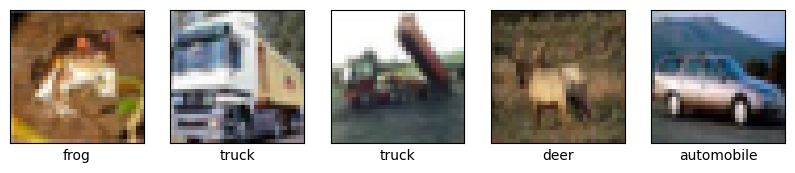

In [ ]:
# Plotting 5 images from the training dataset with label
plt.figure(figsize=(10,2))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.xticks([]), plt.yticks([]), plt.grid(False) # Remove ticks and grid
    plt.imshow(X_train[i]) # Show image
    plt.xlabel(class_names[int(y_train[i])]) # Show label


### **Build CNN Model**

In [ ]:
model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)), # First convolutional layer
    layers.MaxPooling2D((2,2)), # First pooling layer
    layers.Conv2D(64, (3,3), activation='relu'),# Second convolutional layer
    layers.MaxPooling2D((2,2)), # Second pooling layer
    layers.Conv2D(64, (3,3), activation='relu'),  # Third convolutional layer
    layers.Flatten(),  # Flatten to 1D
    layers.Dense(64, activation='relu'), # Fully connected layer
    layers.Dense(10)  # output for 10 classes
])


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### **Train Model**

In [ ]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

history = model.fit(X_train, y_train, epochs=10,
                    validation_data=(X_test, y_test))


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 87s 53ms/step - accuracy: 0.3577 - loss: 1.7435 - val_accuracy: 0.5300 - val_loss: 1.3124
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 133s 47ms/step - accuracy: 0.5777 - loss: 1.1897 - val_accuracy: 0.6118 - val_loss: 1.0842
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 75s 48ms/step - accuracy: 0.6477 - loss: 1.0031 - val_accuracy: 0.6233 - val_loss: 1.0985
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 81s 47ms/step - accuracy: 0.6852 - loss: 0.9050 - val_accuracy: 0.6730 - val_loss: 0.9400
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 83s 48ms/step - accuracy: 0.7150 - loss: 0.8144 - val_accuracy: 0.6963 - val_loss: 0.8663
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 88s 52ms/step - accuracy: 0.7382 - loss: 0.7551 - val_accuracy: 0.6936 - val_loss: 0.8866
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 76s 48ms/step - accuracy: 0.7578 - loss: 0.6940 - val_accuracy: 0.7168 - val_loss: 0.8365
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 80s 47ms/step - accuracy: 0.7717 

Plot Accuracy Graph

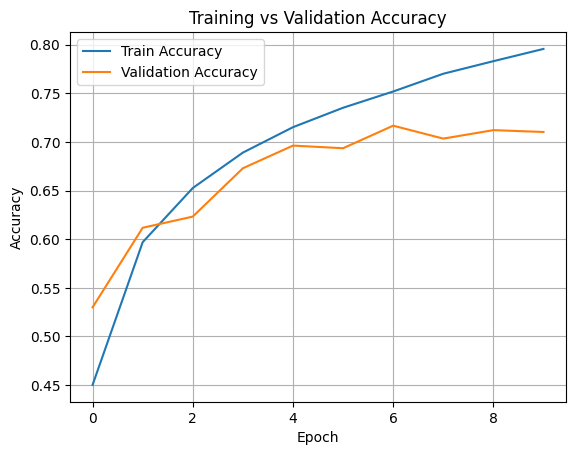

In [ ]:
# Plot training and validation accuracy to visualize learning performance
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch'), plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend(), plt.grid(True)
plt.show()


**Model Evaluation**

In [ ]:
# Evaluate the model on the test dataset to get final accuracy and loss
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=2)
print(f"\n Test accuracy: {test_acc:.2f}")


313/313 - 5s - 15ms/step - accuracy: 0.7103 - loss: 0.8881

 Test accuracy: 0.71


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step


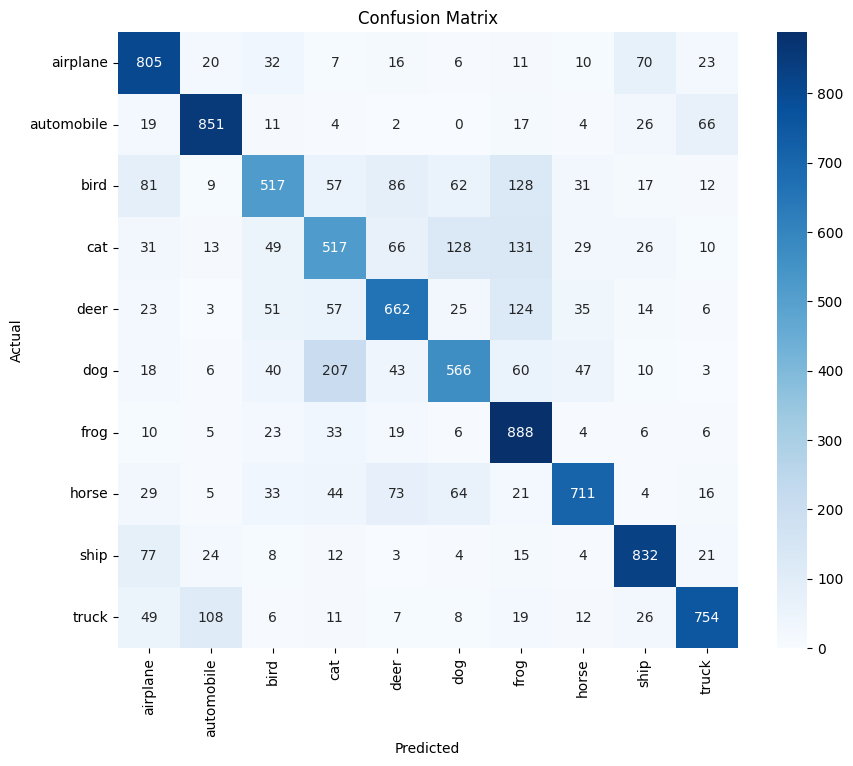

Classification Report:

              precision    recall  f1-score   support

    airplane       0.70      0.81      0.75      1000
  automobile       0.82      0.85      0.83      1000
        bird       0.67      0.52      0.58      1000
         cat       0.54      0.52      0.53      1000
        deer       0.68      0.66      0.67      1000
         dog       0.65      0.57      0.61      1000
        frog       0.63      0.89      0.74      1000
       horse       0.80      0.71      0.75      1000
        ship       0.81      0.83      0.82      1000
       truck       0.82      0.75      0.79      1000

    accuracy                           0.71     10000
   macro avg       0.71      0.71      0.71     10000
weighted avg       0.71      0.71      0.71     10000



In [ ]:
# Predict classes using the trained model
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test.flatten()
# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
# Visualize the confusion matrix
plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted'), plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()
# Print classification report
print("Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names))


# **Conclusion**

We successfully built and trained a CNN model for image classification using the CIFAR-10 dataset. The model achieved an accuracy of approximately 0.71% , showing it learned to classify images reasonably well.

#**Future Improvements**
- Use data augmentation to improve generalization
- Add dropout layers to prevent overfitting
- Try transfer learning with pretrained models like ResNet or MobileNet


# **Methodology**

1. **Dataset Selection**: We used the CIFAR-10 dataset, which contains 60,000 labeled images across 10 classes.
2. **Data Preprocessing**: All images were normalized by dividing pixel values by 255 to improve model training speed and performance.
3. **Model Building**: We created a Convolutional Neural Network (CNN) using TensorFlow and Keras, with three convolutional layers followed by dense layers.
4. **Training and Evaluation**: The model was trained for 10 epochs. Accuracy and loss were evaluated on the test dataset.
5. **Performance Analysis**: We visualized training vs validation accuracy, generated a confusion matrix, and printed a classification report to understand how well the model performs.

# **Challenges Faced**

1. **Understanding CNN Layers**: As a beginner, it was initially difficult to understand how convolutional, pooling, and dense layers work together.
2. **Library Familiarity**: TensorFlow and Keras were new tools for me, and I wasn’t sure about the right syntax or functions at first.
3. **Model Accuracy Fluctuations**: During training, the validation accuracy did not always increase, which made me think something was wrong.
4. **Confusion Matrix Code**: Generating and displaying the confusion matrix correctly required extra effort and external help.

# **How I Overcame Them**
1. **Simple Model First**: I started with a small CNN and gradually added more layers to understand each one’s role.
2. **Used Documentation**: I relied on TensorFlow and Keras documentation, online forums like Stack Overflow, and beginner tutorials to understand the code.
3. **Visual Debugging**: By plotting accuracy graphs and printing values after each epoch, I could verify that the model was learning correctly.
4. **Step-by-step Help**: I followed structured, guided help (like this!) to implement and test each block separately, which made debugging easy.

These challenges helped me understand how deep learning workflows are structured and improved my confidence in using Python for AI projects.